<a href="https://colab.research.google.com/github/r4k0nb4k0n/browser-engineering-study/blob/main/part-2-viewing-documents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3장 Formatting text

## 3.1 What is a Font?


In [2]:
import tkinter.font
window = tkinter.Tk()
bi_times = tkinter.font.Font(
    family="Times",
    size=16,
    weight="bold",
    slant="italic",
)

## 3.2 Measuring Text

In [3]:
bi_times.metrics()

{'ascent': 19, 'descent': 5, 'linespace': 24, 'fixed': 0}

In [4]:
bi_times.measure("Hi!")

30

In [5]:
tkinter.font.Font(family="Courier", size=16).metrics()

{'ascent': 17, 'descent': 6, 'linespace': 23, 'fixed': 1}

In [6]:
tkinter.font.Font(family="Times", size=16).metrics()

{'ascent': 18, 'descent': 5, 'linespace': 23, 'fixed': 0}

In [7]:
tkinter.font.Font(family="Helvetica", size=16).metrics()

{'ascent': 19, 'descent': 5, 'linespace': 24, 'fixed': 0}

In [8]:
bi_times.measure("Hi!")

30

In [9]:
bi_times.measure("H")

16

In [10]:
bi_times.measure("i")

6

In [11]:
bi_times.measure("!")

8

In [12]:
13 + 5 + 7

25

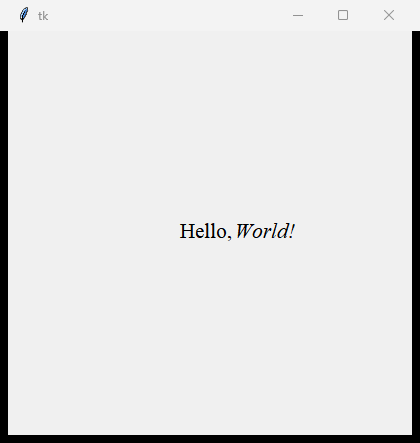

In [13]:
font1 = tkinter.font.Font(family="Times", size=16)
font2 = tkinter.font.Font(family="Times", size=16, slant='italic')

canvas = tkinter.Canvas(window, width=400, height=400)
canvas.pack()

x, y = 200, 200
canvas.create_text(x, y, text="Hello, ", font=font1)
x += font1.measure("Hello, ")
canvas.create_text(x, y, text="World!", font=font2)

from browser import display_tk_window
display_tk_window(window)

## 3.3 Word by Word

In [14]:
import tkinter
from browser.url import URL, lex
from browser.tk_capture import display_tk_window

WIDTH, HEIGHT = 800, 600
HSTEP, VSTEP = 13, 18
SCROLL_STEP = 100

def layout(text):
    font = tkinter.font.Font()
    display_list = []
    cursor_x, cursor_y = HSTEP, VSTEP
    for word in text.split():
        w = font.measure(word)
        display_list.append((cursor_x, cursor_y, word))
        cursor_x += w + font.measure(" ")
        if cursor_x + w > WIDTH - HSTEP:
            cursor_y += font.metrics("linespace") * 1.25
            cursor_x = HSTEP
    return display_list

class Browser:
    def __init__(self):
        self.window = tkinter.Tk()
        self.canvas = tkinter.Canvas(self.window, width=WIDTH, height=HEIGHT)
        self.canvas.pack()
        self.scroll = 0
        self.window.bind("<Down>", self.scrolldown)

    def display(self):
        display_tk_window(self.window)

    def draw(self):
        self.canvas.delete("all")
        for x, y, c in self.display_list:
            self.canvas.create_text(x, y - self.scroll, text=c)

    def scrolldown(self, e=None):
        self.scroll += SCROLL_STEP
        self.draw()

    def load(self, url, headers=None):
        body = url.request(headers=headers)
        text = lex(body, url.scheme)
        self.display_list = layout(text)
        self.draw()

browser = Browser()
browser.load(URL("https://info.cern.ch/hypertext/WWW/TheProject.html"))
browser.display()

AttributeError: 'list' object has no attribute 'split'

## 3.6 Text of Different Sizes


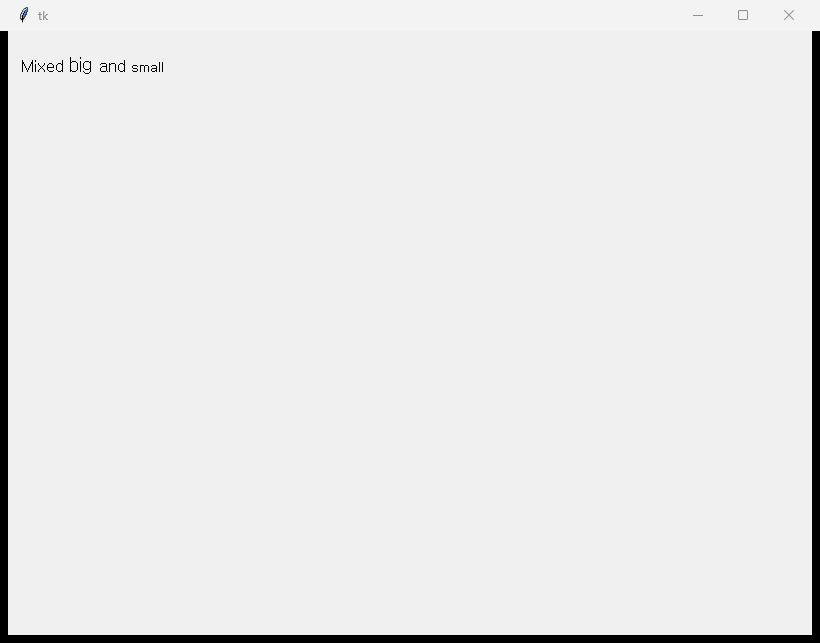

In [ ]:
import tkinter
from browser import URL, display_tk_window
from browser.html import lex
from browser.layout import Layout, WIDTH, HEIGHT

SCROLL_STEP = 100


class Browser:
    def __init__(self):
        self.window = tkinter.Tk()
        self.canvas = tkinter.Canvas(self.window, width=WIDTH, height=HEIGHT)
        self.canvas.pack()
        self.scroll = 0
        self.window.bind("<Down>", self.scrolldown)

    def display(self):
        display_tk_window(self.window)

    def draw(self):
        self.canvas.delete("all")
        for x, y, word, font in self.display_list:
            self.canvas.create_text(
                x, y - self.scroll, text=word, font=font, anchor="nw"
            )

    def scrolldown(self, e=None):
        self.scroll += SCROLL_STEP
        self.draw()

    def load(self, url, headers=None):
        body = url.request(headers=headers)
        self.display_list = Layout(lex(body)).display_list
        self.draw()


browser = Browser()
browser.load(URL("https://browser.engineering/examples/example3-sizes.html"))
browser.display()


## 3.10 Exercise

### 3-1 Centered text. The page titles on this book’s website are centered; make your browser do the same for text between <h1 class="title"> and </h1>. Each line has to be centered individually, because different lines will have different lengths.In early HTML there was a <center> tag that did exactly this, but nowadays centering is typically done in CSS, through the text-align property. The approach in this exercise is of course non-standard, and just for learning purposes.

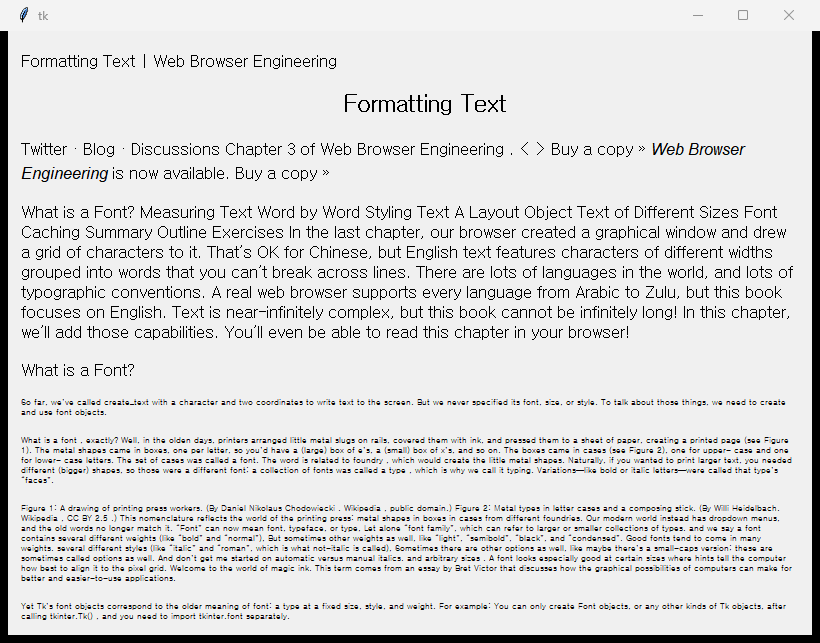

In [1]:
import tkinter
from browser import URL, display_tk_window
from browser.html import lex
from browser.layout import Layout, WIDTH, HEIGHT

SCROLL_STEP = 100


class Browser:
    def __init__(self):
        self.window = tkinter.Tk()
        self.canvas = tkinter.Canvas(self.window, width=WIDTH, height=HEIGHT)
        self.canvas.pack()
        self.scroll = 0
        self.window.bind("<Down>", self.scrolldown)

    def display(self):
        display_tk_window(self.window)

    def draw(self):
        self.canvas.delete("all")
        for x, y, word, font in self.display_list:
            self.canvas.create_text(
                x, y - self.scroll, text=word, font=font, anchor="nw"
            )

    def scrolldown(self, e=None):
        self.scroll += SCROLL_STEP
        self.draw()

    def load(self, url, headers=None):
        body = url.request(headers=headers)
        self.display_list = Layout(lex(body)).display_list
        self.draw()


browser = Browser()
browser.load(URL("https://browser.engineering/text.html"))
browser.display()
